# Modulation Learning for Pouring Task

## Setup

In [1]:
# 1. Load the autoreload extension
%load_ext autoreload

# 2. Set it to reload everything before executing a cell
%autoreload 2

import joblib, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.spatial.transform import Slerp
from scipy.spatial.transform import RotationSpline
from scipy.interpolate import CubicSpline, interp1d
from scipy.linalg import null_space

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as CK, WhiteKernel as WK

from src.se3_lpvds.src.util import plot_tools, load_tools, process_tools, quat_tools
from src.se3_lpvds.src.se3_class import se3_class
from src.se3_lpvds.src.quaternion_ds.src.util.plot_tools import plot_traj as plot_traj_ori

In [2]:
# ── Trajectory indices ──────────────────────────────────────────────────────
START_IDX      = 0
END_IDX        = 150
N_STEPS_AFTER  = 400   # original DS continuation after boundary

# ── Initial condition sampling ───────────────────────────────────────────────
N_IC           = 2
N_VAL          = 2     # validation trajectories (held out from GP training)
DEV_NEAR_DEG   = 15.0   # perturbation radius for nearby ICs

# ── GP / uncertainty rollout ─────────────────────────────────────────────────
CONFIDENCE_THR = 2.0   # sigmoid midpoint for uncertainty blending
N_RESTARTS     = 15    # GPR optimizer restarts

# ── Boundary taper ───────────────────────────────────────────────────────────
TAPER_FRAC     = 0.6   # cosine-taper the last 30% of training targets to zero

# ── Input-space distance gate ────────────────────────────────────────────────
GATE_BANDWIDTH = 1.0   # RBF bandwidth for suppressing y_pred far from training data

In [3]:
# Load original DS
ori_file_name = "pouring-original"
se3_obj = se3_class.load("models/" + ori_file_name + "_ds.pkl")
quat_obj = se3_obj.ori_ds

# Load modulated DS
mod_file_name = "pouring-modulated"
mod_obj = se3_class.load("models/" + mod_file_name + "_ds.pkl")
quat_mod_obj = mod_obj.ori_ds

dt = se3_obj.dt
T = se3_obj.T

# Original DS initial and attractor
ori_q_0 = se3_obj.q_in[0]
ori_p_0 = se3_obj.p_in[0]
ori_q_att = se3_obj.q_att
ori_p_att = se3_obj.p_att

# Modulated DS initial and attractor
mod_q_0 = mod_obj.q_in[0]
mod_p_0 = mod_obj.p_in[0]
mod_q_att = mod_obj.q_att
mod_p_att = mod_obj.p_att

[INFO] Model loaded successfully from models/pouring-original_ds.pkl
[INFO] Model loaded successfully from models/pouring-modulated_ds.pkl


## Data Preparation

In [4]:
def generate_nearby_rotations(ref_rot, num_samples=10, max_deviation_deg=5.0):
    random_vectors = np.random.randn(num_samples, 3)
    random_axes = random_vectors / np.linalg.norm(random_vectors, axis=1, keepdims=True)
    max_rad = np.radians(max_deviation_deg)
    random_angles = np.random.uniform(0, max_rad, size=(num_samples, 1))
    perturbation_vecs = random_axes * random_angles
    perturbations = R.from_rotvec(perturbation_vecs)
    random_starts = perturbations * ref_rot
    return random_starts


# Simulate original DS trajectories
near_q0_list = generate_nearby_rotations(ori_q_0, N_IC, max_deviation_deg=DEV_NEAR_DEG)
sim_results = []
for i, q_start in enumerate(near_q0_list):
    p_res, q_res, _, _, _, _ = se3_obj.sim(
        ori_p_0, q_start, ori_p_att, ori_q_att, dt, duration=T*2
    )
    traj_rot = R.concatenate(q_res)
    traj_time = np.arange(0, dt * len(traj_rot), dt)
    sim_results.append({"q": traj_rot, "t": traj_time, "label": f"Ori {i}"})

# Simulate modulated DS trajectories (training)
train_q0_list = generate_nearby_rotations(mod_q_0, N_IC, max_deviation_deg=DEV_NEAR_DEG)
train_results = []
for i, q_start in enumerate(train_q0_list):
    p_res, q_res, _, _, _, _ = mod_obj.sim(
        mod_p_0, q_start, mod_p_att, mod_q_att, dt, duration=T*2
    )
    traj_rot = R.concatenate(q_res)
    traj_time = np.arange(0, dt * len(traj_rot), dt)
    train_results.append({"q": traj_rot, "t": traj_time, "label": f"Mod {i}"})

# Simulate modulated DS trajectories (validation — unseen ICs)
mod_val_q0_list = generate_nearby_rotations(mod_q_0, N_VAL, max_deviation_deg=DEV_NEAR_DEG)
mod_val_results = []
for i, q_start in enumerate(mod_val_q0_list):
    p_res, q_res, _, _, _, _ = mod_obj.sim(
        mod_p_0, q_start, mod_p_att, mod_q_att, dt, duration=T*2
    )
    traj_rot = R.concatenate(q_res)
    traj_time = np.arange(0, dt * len(traj_rot), dt)
    mod_val_results.append({"q": traj_rot, "t": traj_time, "label": f"Val {i}"})

t_in = sim_results[0]["t"]

Converged within max iteration
Converged within max iteration
Converged within max iteration
Converged within max iteration
Converged within max iteration
Converged within max iteration


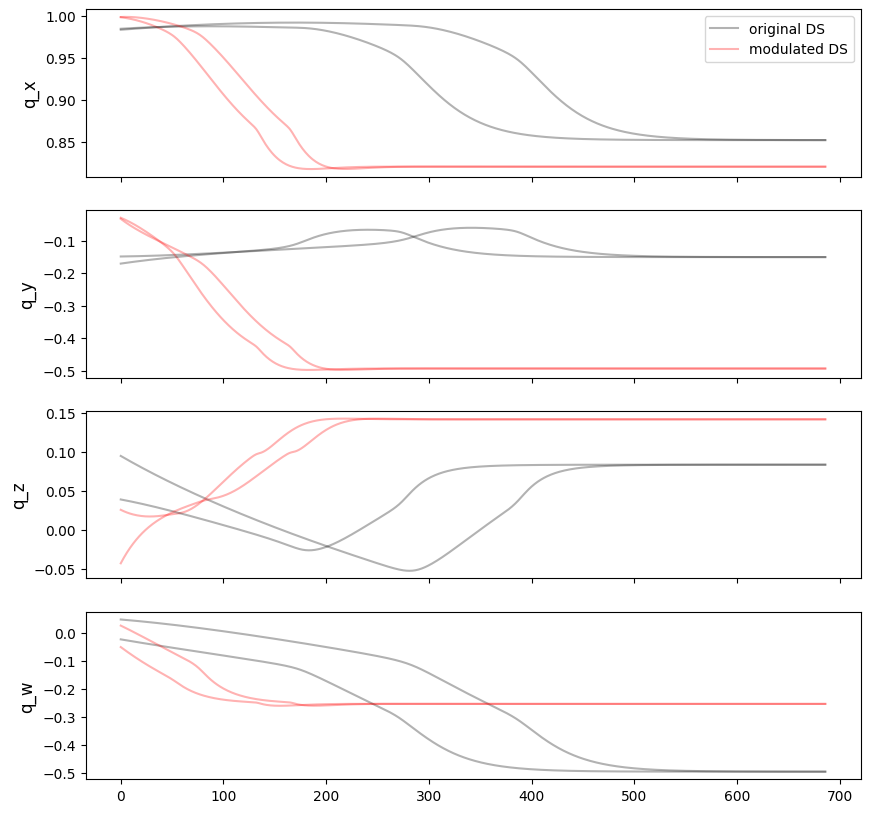

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
component_names = ['x', 'y', 'z', 'w']

# Plot training data from modulated DS
# mod_q_in = R.concatenate(list(mod_obj.q_in))
# for i, (ax, name) in enumerate(zip(axes, component_names)):
#     ax.plot(mod_q_in.as_quat()[:, i], 'b--', alpha=0.5, label='mod DS training data', linewidth=1.5)

for idx in range(N_IC):
    if idx == 0:
        for i, (ax, name) in enumerate(zip(axes, component_names)):
            ax.plot(sim_results[idx]["q"].as_quat()[:, i], 'k-', alpha=0.3, label='original DS', linewidth=1.5)
            ax.plot(train_results[idx]["q"].as_quat()[:, i], 'r-', alpha=0.3, label='modulated DS', linewidth=1.5)
            ax.set_ylabel(f'q_{name}', fontsize=12)
    else:
        for i, (ax, name) in enumerate(zip(axes, component_names)):
            ax.plot(sim_results[idx]["q"].as_quat()[:, i], 'k-', alpha=0.3, linewidth=1.5)
            ax.plot(train_results[idx]["q"].as_quat()[:, i], 'r-', alpha=0.3, linewidth=1.5)
axes[0].legend(loc='best')

In [6]:
def compute_original_output(q):
    q_out_orig = []
    for q_i in q:
        q_next, _, _ = quat_obj._step(q_i, dt)
        q_out_orig.append(q_next)
    return R.concatenate(q_out_orig)

q_in_train_list = []
q_out_train_list = []
q_out_train_orig_list = []

for q_interp in train_results:
    q_in_train     = q_interp['q'][START_IDX: END_IDX - 1]
    q_out_train    = q_interp['q'][START_IDX + 1: END_IDX]
    q_out_orig = compute_original_output(q_in_train)
    q_in_train_list.append(q_in_train)
    q_out_train_list.append(q_out_train)
    q_out_train_orig_list.append(q_out_orig)

q_in_val_list = []
q_out_val_list = []
q_out_val_orig_list = []

for q_interp in mod_val_results:
    q_in_v          = q_interp['q'][START_IDX: END_IDX - 1]
    q_out_v         = q_interp['q'][START_IDX + 1: END_IDX]
    q_out_val_orig  = compute_original_output(q_in_v)
    q_in_val_list.append(q_in_v)
    q_out_val_list.append(q_out_v)
    q_out_val_orig_list.append(q_out_val_orig)

In [7]:
def map(att_vec, q):
    """Map 4-D quaternion tangent vector to 3-D via attractor null-space basis."""
    att_basis = null_space(att_vec.as_quat().reshape(1, -1))
    v, _, _, _ = np.linalg.lstsq(att_basis, q, rcond=None)
    return v

def inv_map(att_vec, v):
    """Inverse: 3-D → 4-D quaternion tangent vector."""
    att_basis = null_space(att_vec.as_quat().reshape(1, -1))
    return att_basis @ v

def modulation_param(x_ori, x_mod):
    mu = np.cross(x_ori, x_mod)
    mu = mu / np.linalg.norm(mu + 1e-10)
    phi = np.arccos(np.clip(
        np.dot(x_ori, x_mod) / (np.linalg.norm(x_ori) * np.linalg.norm(x_mod)),
        -1.0, 1.0))
    kappa = np.linalg.norm(x_mod) / np.linalg.norm(x_ori) - 1.0
    return mu, phi, kappa

def modulation_matrix(mu_phi, kappa):
    return (1 + kappa) * R.from_rotvec(mu_phi).as_matrix()

def att_tangent_3d(q_att, q_in, q_out):
    """Riemannian log of q_out at q_in, parallel-transported to q_att frame, projected to 3D."""
    q_out_body   = quat_tools.riem_log(q_in, q_out)
    q_out_att_4d = quat_tools.parallel_transport(q_in, q_att, q_out_body)[0]
    return map(q_att, q_out_att_4d)

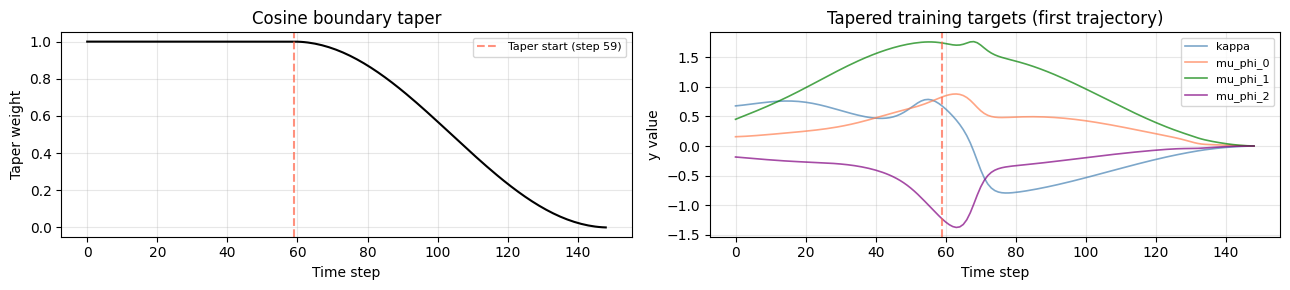

In [8]:
X_train = []
y_train = []
q_out_3d   = []
q_out_o_3d = []

idx_train = np.arange(0, END_IDX - START_IDX - 1)

for q_in_train, q_out_train, q_out_orig in zip(q_in_train_list, q_out_train_list, q_out_train_orig_list):
    for qin, qout, qout_o in zip(q_in_train, q_out_train, q_out_orig):
        q_out_att   = att_tangent_3d(ori_q_att, qin, qout)
        q_out_att_m = att_tangent_3d(ori_q_att, qin, qout_o)
        q_out_3d.append(q_out_att)
        q_out_o_3d.append(q_out_att_m)

        mu, phi, kappa = modulation_param(q_out_att_m, q_out_att)
        X_train.append(quat_tools.riem_log(ori_q_att, qin))
        y_train.append(np.hstack((kappa, phi * mu[0], phi * mu[1], phi * mu[2])).reshape(1, -1))

X_train = np.vstack(X_train)
y_train = np.vstack(y_train)

# ── Cosine taper: force y_train → 0 over the last TAPER_FRAC of the window ──
n_steps     = len(idx_train)
taper_start = int((1 - TAPER_FRAC) * n_steps)
taper       = np.ones(n_steps)
taper[taper_start:] = 0.5 * (1 + np.cos(
    np.pi * np.arange(n_steps - taper_start) / (n_steps - taper_start)
))
taper_all = np.tile(taper, len(q_in_train_list))   # repeat across trajectories
y_train   = y_train * taper_all[:, None]

X_val = []
y_val = []

for q_in_v, q_out_v, q_out_val_orig in zip(q_in_val_list, q_out_val_list, q_out_val_orig_list):
    for qin, qout, qout_o in zip(q_in_v, q_out_v, q_out_val_orig):
        q_out_att   = att_tangent_3d(ori_q_att, qin, qout)
        q_out_att_m = att_tangent_3d(ori_q_att, qin, qout_o)

        mu, phi, kappa = modulation_param(q_out_att_m, q_out_att)
        X_val.append(quat_tools.riem_log(ori_q_att, qin))
        y_val.append(np.hstack((kappa, phi * mu[0], phi * mu[1], phi * mu[2])).reshape(1, -1))

X_val = np.vstack(X_val)
y_val = np.vstack(y_val)

q_out_3d   = np.vstack(q_out_3d)
q_out_o_3d = np.vstack(q_out_o_3d)

# ── Plot taper shape ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3))

axes[0].plot(idx_train, taper, 'k-', linewidth=1.5)
axes[0].axvline(taper_start, color='tomato', linestyle='--', alpha=0.7,
                label=f'Taper start (step {taper_start})')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Taper weight')
axes[0].set_title('Cosine boundary taper')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

y_labels_local = ['kappa', 'mu_phi_0', 'mu_phi_1', 'mu_phi_2']
colors_local   = ['steelblue', 'coral', 'green', 'purple']
for k, (lbl, col) in enumerate(zip(y_labels_local, colors_local)):
    axes[1].plot(idx_train, y_train[:n_steps, k], color=col, linewidth=1.2,
                 alpha=0.7, label=lbl)
axes[1].axvline(taper_start, color='tomato', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('y value')
axes[1].set_title('Tapered training targets (first trajectory)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## GP Training

In [9]:
from sklearn.metrics import r2_score, mean_squared_error
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

n_traj = len(q_in_train_list)
traj_len = len(idx_train)

print("=" * 80)
print("LEAVE-ONE-TRAJECTORY-OUT CROSS-VALIDATION")
print("=" * 80)

test_configs = [
    ('RBF',    None, 1.0, 0.5, 0.01),
    ('RBF',    None, 1.0, 0.1, 0.01),
    ('RBF',    None, 0.3, 0.5, 0.01),
    ('Matern', 1.5,  1.0, 0.5, 0.01),
    ('Matern', 2.5,  1.0, 0.5, 0.01),
    ('Matern', 0.5,  1.0, 0.5, 0.01),
]

traj_cv_results = []

for kernel_type, nu, sigma_f, length_scale, sigma_n in tqdm(test_configs, desc="Trajectory CV"):
    if kernel_type == 'RBF':
        kernel = (
            CK(sigma_f**2, (1e-4, 1e4)) *
            RBF(length_scale=length_scale, length_scale_bounds=(1e-3, 1e2)) +
            WK(noise_level=sigma_n**2, noise_level_bounds=(1e-6, 1.0))
        )
    else:
        kernel = (
            CK(sigma_f**2, (1e-4, 1e4)) *
            Matern(length_scale=length_scale, length_scale_bounds=(1e-3, 1e2), nu=nu) +
            WK(noise_level=sigma_n**2, noise_level_bounds=(1e-6, 1.0))
        )

    r2_scores  = []
    mse_scores = []

    for test_traj_idx in range(n_traj):
        train_mask = np.ones(len(X_train), dtype=bool)
        train_mask[test_traj_idx * traj_len:(test_traj_idx + 1) * traj_len] = False

        X_tr, y_tr = X_train[train_mask],  y_train[train_mask]
        X_te, y_te = X_train[~train_mask], y_train[~train_mask]

        gpr_test = GaussianProcessRegressor(
            kernel=kernel, normalize_y=False, n_restarts_optimizer=3, random_state=42
        )
        gpr_test.fit(X_tr, y_tr)
        y_pred = gpr_test.predict(X_te)

        r2_scores.append(r2_score(y_te, y_pred))
        mse_scores.append(mean_squared_error(y_te, y_pred))

    traj_cv_results.append({
        'kernel': kernel_type, 'nu': nu, 'sigma_f': sigma_f,
        'length_scale': length_scale, 'sigma_n': sigma_n,
        'r2_mean': np.mean(r2_scores), 'r2_std': np.std(r2_scores),
        'mse_mean': np.mean(mse_scores), 'mse_std': np.std(mse_scores)
    })

print("\nRESULTS (Leave-One-Trajectory-Out):")
print("=" * 80)
df_traj = pd.DataFrame(traj_cv_results).sort_values('r2_mean', ascending=False)
for _, row in df_traj.iterrows():
    nu_str = f"ν={row['nu']}" if row['nu'] else "    "
    print(f"{row['kernel']:6s} {nu_str} | σ_f={row['sigma_f']:.1f} | l={row['length_scale']:.2f} | "
          f"σ_n={row['sigma_n']:.2f} | R2={row['r2_mean']:.4f}±{row['r2_std']:.4f} | "
          f"MSE={row['mse_mean']:.6f}")

print("\n" + "=" * 80)
best_traj = df_traj.iloc[0]
print("BEST FOR GENERALIZATION:")
print(f"  Kernel: {best_traj['kernel']}" + (f" (nu={best_traj['nu']})" if best_traj['nu'] else ""))
print(f"  sigma_f: {best_traj['sigma_f']}, length_scale: {best_traj['length_scale']}, sigma_n: {best_traj['sigma_n']}")
print(f"  R2: {best_traj['r2_mean']:.4f} ± {best_traj['r2_std']:.4f}")

LEAVE-ONE-TRAJECTORY-OUT CROSS-VALIDATION


Trajectory CV: 100%|██████████| 6/6 [00:04<00:00,  1.47it/s]


RESULTS (Leave-One-Trajectory-Out):
Matern ν=2.5 | σ_f=1.0 | l=0.50 | σ_n=0.01 | R2=-0.3763±0.2155 | MSE=0.438352
Matern ν=1.5 | σ_f=1.0 | l=0.50 | σ_n=0.01 | R2=-0.6341±0.0788 | MSE=0.455131
Matern ν=0.5 | σ_f=1.0 | l=0.50 | σ_n=0.01 | R2=-0.6489±0.1388 | MSE=0.453232
RBF    ν=nan | σ_f=0.3 | l=0.50 | σ_n=0.01 | R2=-1.1970±0.0325 | MSE=0.691887
RBF    ν=nan | σ_f=1.0 | l=0.50 | σ_n=0.01 | R2=-1.1970±0.0325 | MSE=0.691887
RBF    ν=nan | σ_f=1.0 | l=0.10 | σ_n=0.01 | R2=-1.1970±0.0325 | MSE=0.691887

BEST FOR GENERALIZATION:
  Kernel: Matern (nu=2.5)
  sigma_f: 1.0, length_scale: 0.5, sigma_n: 0.01
  R2: -0.3763 ± 0.2155


In [10]:
# Train final model with best parameters from trajectory CV
best = df_traj.iloc[0]

if best['kernel'] == 'RBF':
    best_kernel = (
        CK(best['sigma_f']**2, (1e-4, 1e4)) *
        RBF(length_scale=best['length_scale'], length_scale_bounds=(1e-3, 1e2)) +
        WK(noise_level=best['sigma_n']**2, noise_level_bounds=(1e-6, 1.0))
    )
else:
    best_kernel = (
        CK(best['sigma_f']**2, (1e-4, 1e4)) *
        Matern(length_scale=best['length_scale'], length_scale_bounds=(1e-3, 1e2), nu=best['nu']) +
        WK(noise_level=best['sigma_n']**2, noise_level_bounds=(1e-6, 1.0))
    )

gpr = GaussianProcessRegressor(
    kernel=best_kernel,
    normalize_y=False,   # keep zero prior mean so GP extrapolates toward 0
    n_restarts_optimizer=N_RESTARTS,
    random_state=42
)

gpr.fit(X_train, y_train)

print("Final model trained!")
print(f"Optimized kernel: {gpr.kernel_}")
print(f"Log-marginal-likelihood: {gpr.log_marginal_likelihood_value_:.4f}")

joblib.dump(gpr, "models/pouring_gpr.pkl")
print("\nModel saved to models/pouring_gpr.pkl")

Final model trained!
Optimized kernel: 2.28**2 * Matern(length_scale=0.113, nu=2.5) + WhiteKernel(noise_level=1e-06)
Log-marginal-likelihood: 4579.3909

Model saved to models/pouring_gpr.pkl


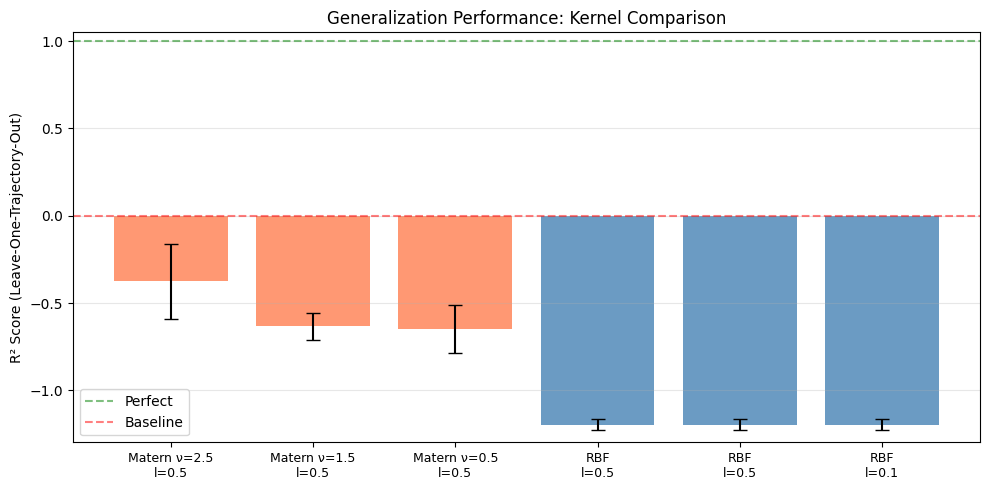

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

labels  = []
r2_means = []
r2_stds  = []
colors   = []

for _, row in df_traj.iterrows():
    if row['kernel'] == 'RBF':
        labels.append(f"RBF\nl={row['length_scale']}")
        colors.append('steelblue')
    else:
        labels.append(f"Matern ν={row['nu']}\nl={row['length_scale']}")
        colors.append('coral')
    r2_means.append(row['r2_mean'])
    r2_stds.append(row['r2_std'])

x = np.arange(len(labels))
ax.bar(x, r2_means, yerr=r2_stds, capsize=5, color=colors, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('R² Score (Leave-One-Trajectory-Out)')
ax.set_title('Generalization Performance: Kernel Comparison')
ax.set_ylim([min(0, min(r2_means) - 0.1), 1.05])
ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect')
ax.axhline(y=0.0, color='red',   linestyle='--', alpha=0.5, label='Baseline')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
gpr = joblib.load("models/pouring_gpr.pkl")

# OFFLINE GPR Prediction Rollout and Modulated Output Reconstruction

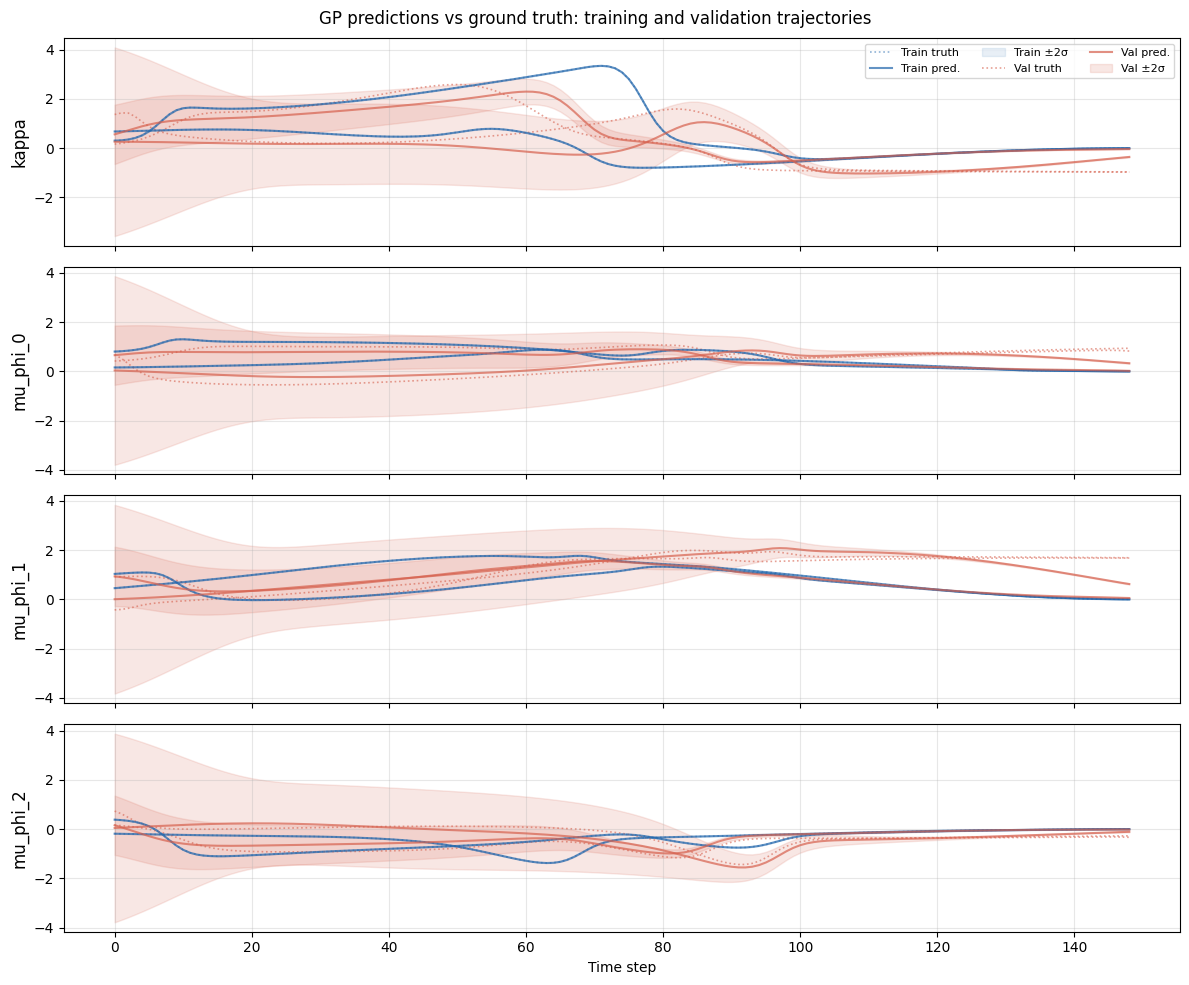

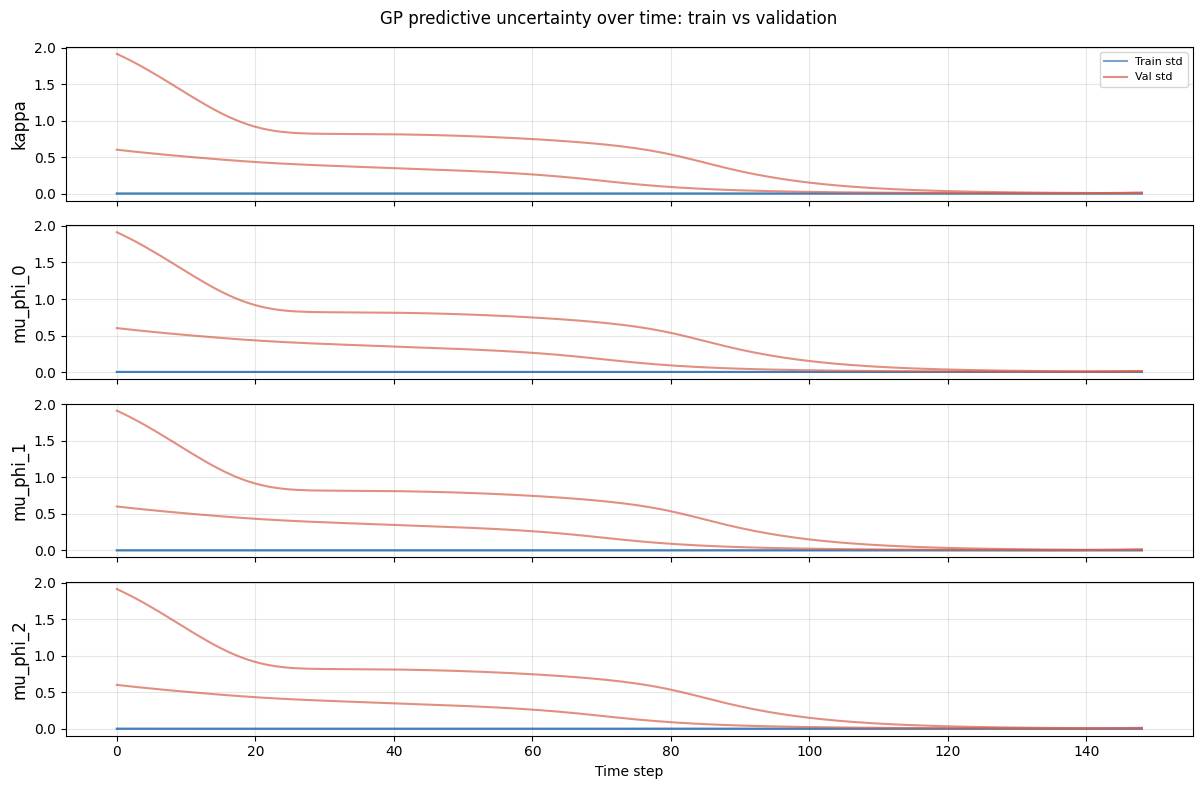

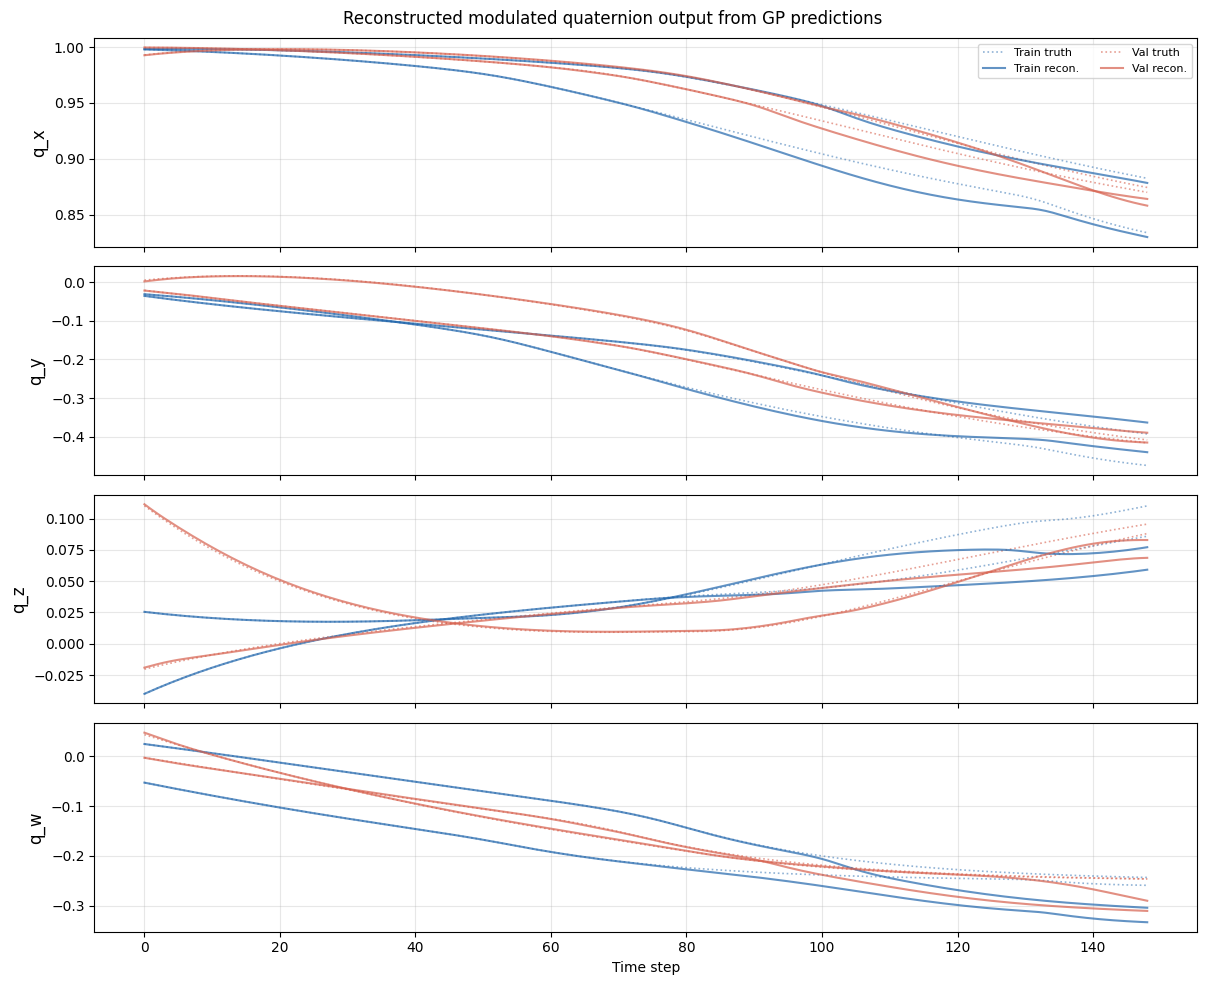

In [13]:
def _std_col(std_arr, k):
    """GPR returns (n,) or (n, n_targets) std — handle both."""
    return std_arr[:, k] if std_arr.ndim == 2 else std_arr


def eval_trajectories(q_in_list, q_out_mod_list, q_out_orig_list):
    """GP prediction + quaternion reconstruction in one pass.

    Returns a list of dicts, one per trajectory, each containing:
      y_pred  : (n, 4)  GP predicted modulation parameters
      y_std   : (n,) or (n, 4)  GP predictive std
      q_true  : R object — ground-truth modulated output quaternions
      q_recon : R object — reconstructed modulated quaternions from y_pred
    """
    results = []
    for q_in_traj, q_out_mod_traj, q_out_orig_traj in zip(q_in_list, q_out_mod_list, q_out_orig_list):
        X = np.vstack([quat_tools.riem_log(ori_q_att, qin) for qin in q_in_traj])
        y_pred, y_std = gpr.predict(X, return_std=True)

        q_recon_traj = []
        for j, (qin, qout_o) in enumerate(zip(q_in_traj, q_out_orig_traj)):
            y_i           = y_pred[j]
            q_out_orig_3d = att_tangent_3d(ori_q_att, qin, qout_o)
            q_out_mod_3d  = modulation_matrix(y_i[1:4], y_i[0]) @ q_out_orig_3d
            q_out_mod_4d  = inv_map(ori_q_att, q_out_mod_3d)
            q_out_body    = quat_tools.parallel_transport(ori_q_att, qin, q_out_mod_4d.reshape(1, -1))
            q_recon_traj.append(R.from_quat(quat_tools.riem_exp(qin, q_out_body).reshape(4)))

        results.append({
            'y_pred':  y_pred,
            'y_std':   y_std,
            'q_true':  q_out_mod_traj,
            'q_recon': R.concatenate(q_recon_traj),
        })
    return results


train_res = eval_trajectories(q_in_train_list,   q_out_train_list,   q_out_train_orig_list)
val_res   = eval_trajectories(q_in_val_list, q_out_val_list, q_out_val_orig_list)

# ── Colour palette ──────────────────────────────────────────────────────────
C_TRAIN = '#2166ac'
C_VAL   = '#d6604d'

component_names = ['kappa', 'mu_phi_0', 'mu_phi_1', 'mu_phi_2']

# ── Figure 1: predictions vs ground truth ───────────────────────────────────
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for i, res in enumerate(train_res):
    sl = slice(i * len(idx_train), (i + 1) * len(idx_train))
    for k in range(4):
        axs[k].plot(idx_train, y_train[sl, k],
                    color=C_TRAIN, linestyle='dotted', alpha=0.5, linewidth=1.2,
                    label="Train truth" if i == 0 else None, zorder=2)
        axs[k].plot(idx_train, res['y_pred'][:, k],
                    color=C_TRAIN, linewidth=1.5, alpha=0.7,
                    label="Train pred." if i == 0 else None, zorder=3)
        axs[k].fill_between(
            idx_train,
            res['y_pred'][:, k] - 2 * _std_col(res['y_std'], k),
            res['y_pred'][:, k] + 2 * _std_col(res['y_std'], k),
            alpha=0.1, color=C_TRAIN, label="Train ±2σ" if i == 0 else None, zorder=1
        )

for i, res in enumerate(val_res):
    sl = slice(i * len(idx_train), (i + 1) * len(idx_train))
    for k in range(4):
        axs[k].plot(idx_train, y_val[sl, k],
                    color=C_VAL, linestyle='dotted', alpha=0.6, linewidth=1.2,
                    label="Val truth" if i == 0 else None, zorder=2)
        axs[k].plot(idx_train, res['y_pred'][:, k],
                    color=C_VAL, linewidth=1.5, alpha=0.7,
                    label="Val pred." if i == 0 else None, zorder=3)
        axs[k].fill_between(
            idx_train,
            res['y_pred'][:, k] - 2 * _std_col(res['y_std'], k),
            res['y_pred'][:, k] + 2 * _std_col(res['y_std'], k),
            alpha=0.15, color=C_VAL, label="Val ±2σ" if i == 0 else None, zorder=1
        )

for k in range(4):
    axs[k].set_ylabel(f'{component_names[k]}', fontsize=12)
    axs[k].grid(True, alpha=0.3)
axs[-1].set_xlabel('Time step')
axs[0].legend(loc='best', fontsize=8, ncol=3)
plt.suptitle('GP predictions vs ground truth: training and validation trajectories')
plt.tight_layout()
plt.show()

# ── Figure 2: GP uncertainty over time ──────────────────────────────────────
fig2, axs2 = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

for k in range(4):
    for i, res in enumerate(train_res):
        axs2[k].plot(idx_train, _std_col(res['y_std'], k),
                     color=C_TRAIN, linewidth=1.5, alpha=0.6,
                     label='Train std' if i == 0 else None)
    for i, res in enumerate(val_res):
        axs2[k].plot(idx_train, _std_col(res['y_std'], k),
                     color=C_VAL, linewidth=1.5, alpha=0.7,
                     label='Val std' if i == 0 else None)
    axs2[k].set_ylabel(f'{component_names[k]}', fontsize=12)
    axs2[k].grid(True, alpha=0.3)

axs2[-1].set_xlabel('Time step')
axs2[0].legend(loc='best', fontsize=8)
plt.suptitle('GP predictive uncertainty over time: train vs validation')
plt.tight_layout()
plt.show()

# ── Figure 3: reconstructed modulated quaternion from predicted y ────────────
quat_labels = ['x', 'y', 'z', 'w']
fig3, axs3 = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for i, res in enumerate(train_res):
    for k in range(4):
        axs3[k].plot(idx_train, res['q_true'].as_quat()[:, k],
                     color=C_TRAIN, linestyle='dotted', alpha=0.5, linewidth=1.2,
                     label='Train truth' if i == 0 else None, zorder=2)
        axs3[k].plot(idx_train, res['q_recon'].as_quat()[:, k],
                     color=C_TRAIN, linewidth=1.5, alpha=0.7,
                     label='Train recon.' if i == 0 else None, zorder=3)

for i, res in enumerate(val_res):
    for k in range(4):
        axs3[k].plot(idx_train, res['q_true'].as_quat()[:, k],
                     color=C_VAL, linestyle='dotted', alpha=0.6, linewidth=1.2,
                     label='Val truth' if i == 0 else None, zorder=2)
        axs3[k].plot(idx_train, res['q_recon'].as_quat()[:, k],
                     color=C_VAL, linewidth=1.5, alpha=0.7,
                     label='Val recon.' if i == 0 else None, zorder=3)

for k in range(4):
    axs3[k].set_ylabel(f'q_{quat_labels[k]}', fontsize=12)
    axs3[k].grid(True, alpha=0.3)
axs3[-1].set_xlabel('Time step')
axs3[0].legend(fontsize=8, ncol=2, loc='best')
plt.suptitle('Reconstructed modulated quaternion output from GP predictions')
plt.tight_layout()
plt.show()

In [14]:
print(train_res[0]['q_true'][0].as_quat())
print(train_res[0]['q_recon'][0].as_quat())

[ 0.99779747 -0.03138104  0.02546513 -0.05260188]
[ 0.99779747 -0.03138104  0.02546513 -0.05260187]


## Uncertainty Rollout

In [15]:
def compute_output(q):
    """Step through q using GP prediction as y_override; return q, y, and per-step std."""
    q_list   = []
    y_list   = []
    std_list = []
    for q_i in q:
        x_input       = quat_tools.riem_log(ori_q_att, q_i).reshape(1, -1)
        y_pred, y_std = gpr.predict(x_input, return_std=True)
        q_next, _, _, _ = quat_obj._step2(q_i, dt, gpr, y_override=y_pred)
        q_list.append(q_next)
        y_list.append(y_pred)
        std_list.append(np.mean(y_std))
    return R.concatenate(q_list), np.vstack(y_list), np.array(std_list)


def _distance_gate(x_input, bandwidth=GATE_BANDWIDTH):
    """RBF gate: weight = exp(-min_dist² / (2·bw²)), where min_dist is the
    distance from x_input to the nearest point in X_train."""
    dists = np.linalg.norm(X_train - x_input, axis=1)
    return float(np.exp(-np.min(dists)**2 / (2 * bandwidth**2)))


def rollout_output(q, idx_test):
    """Rollout with input-space distance gating on the GP prediction."""
    q_curr    = q
    q_list    = []
    y_list    = []
    std_list  = []
    gate_list = []
    for _ in range(idx_test.shape[0]):
        x_input = quat_tools.riem_log(ori_q_att, q_curr).reshape(1, -1)
        y_pred, y_std = gpr.predict(x_input, return_std=True)

        gate   = _distance_gate(x_input)
        y_pred = y_pred * gate

        q_next, _, _, _ = quat_obj._step2(q_curr, dt, gpr, y_override=y_pred)
        q_list.append(q_next)
        y_list.append(y_pred)
        std_list.append(np.mean(y_std))
        gate_list.append(gate)
        q_curr = q_next
    return R.concatenate(q_list), np.vstack(y_list), np.array(std_list), np.array(gate_list)


def ensure_hemisphere(q, q_ref):
    """Flip q to the same hemisphere as q_ref if needed."""
    if np.dot(q.as_quat(), q_ref.as_quat()) < 0:
        return R.from_quat(-q.as_quat())
    return q

idx_test = np.arange(START_IDX, END_IDX + N_STEPS_AFTER)

# q_rollout_m, y_rollout, std_rollout = compute_output(q_in_train_list[0])

q_rollout_m, y_rollout, std_rollout, gate_rollout = rollout_output(q_in_train_list[0][0], idx_test)
# q_rollout_m, y_rollout, std_rollout, gate_rollout = rollout_output(q_in_val_list[0][0], idx_test)

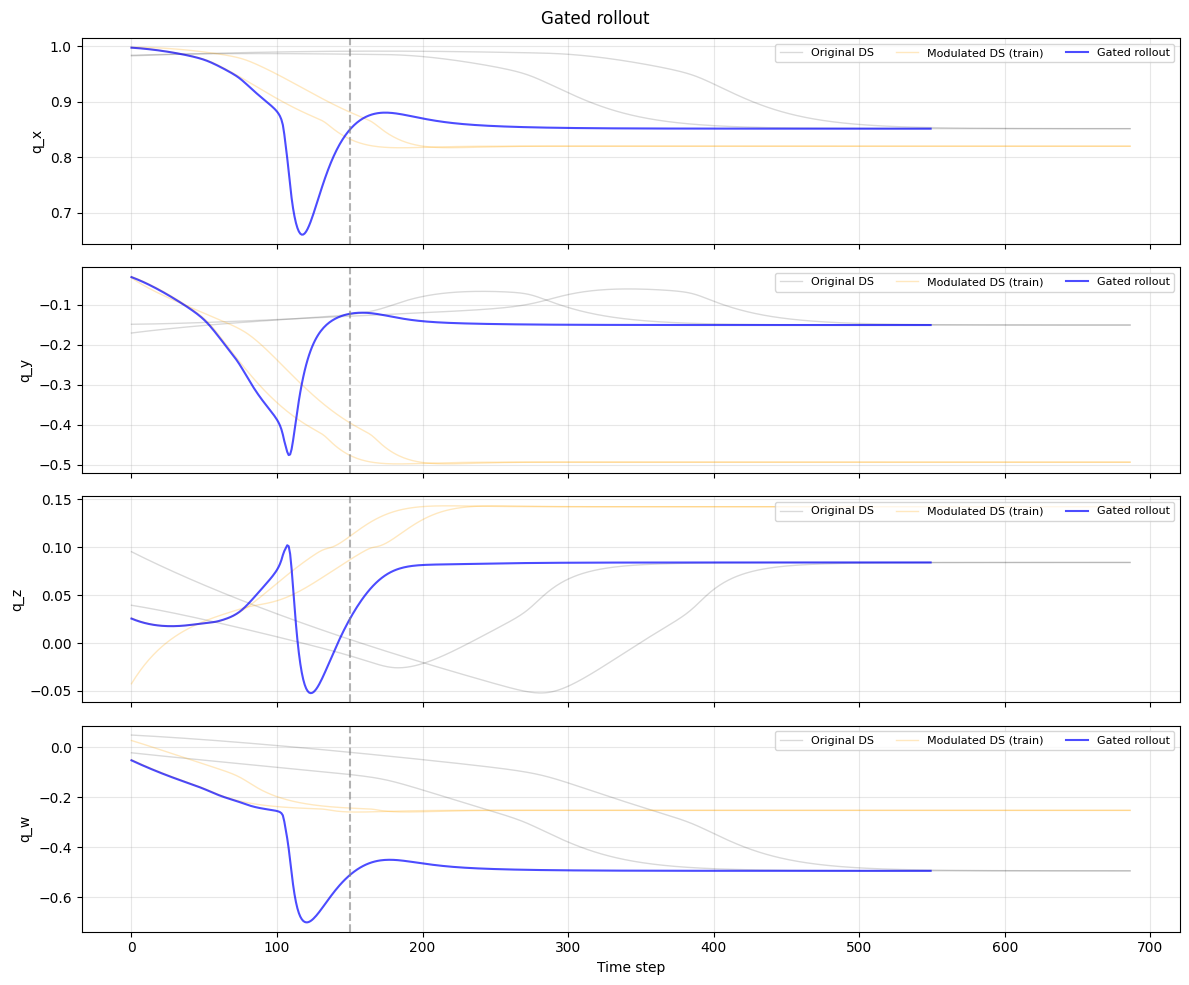

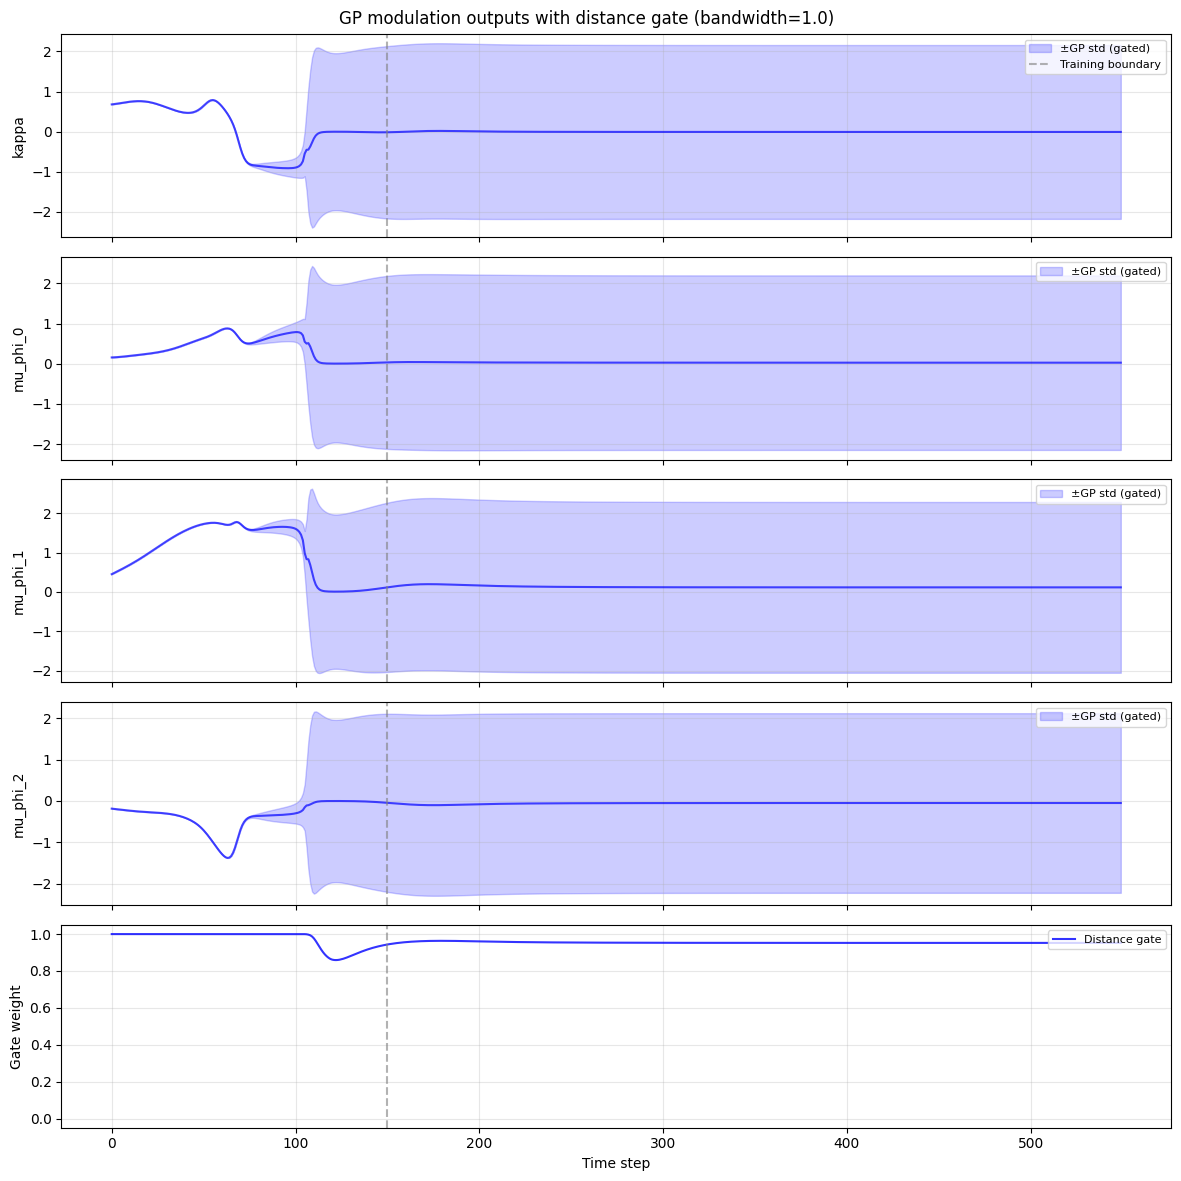

In [16]:
quat_labels = ['x', 'y', 'z', 'w']
y_labels    = ['kappa', 'mu_phi_0', 'mu_phi_1', 'mu_phi_2']

q_rollout_arr = q_rollout_m.as_quat()

# --- Figure 1: Quaternion trajectory ---
fig1, axes1 = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for i, label in enumerate(quat_labels):
    ax = axes1[i]
    for j, res in enumerate(sim_results):
        q_arr = res['q'].as_quat()
        ax.plot(np.arange(len(q_arr)), q_arr[:, i], 'k-', alpha=0.15, linewidth=1,
                label='Original DS' if j == 0 else None)
    for j, res in enumerate(train_results):
        q_arr = res['q'].as_quat()
        ax.plot(np.arange(len(q_arr)), q_arr[:, i], color='orange', alpha=0.25, linewidth=1,
                label='Modulated DS (train)' if j == 0 else None)
    ax.plot(idx_test, q_rollout_arr[:, i], 'b-', linewidth=1.5, alpha=0.7, label='Gated rollout')
    ax.axvline(x=END_IDX, color='gray', linestyle='--', alpha=0.6)
    ax.set_ylabel(f'q_{label}')
    ax.legend(fontsize=8, loc='upper right', ncol=3)
    ax.grid(True, alpha=0.3)
axes1[-1].set_xlabel('Time step')
plt.suptitle('Gated rollout')
plt.tight_layout()
plt.show()

# --- Figure 2: GP modulation outputs (y) with uncertainty and gate weight ---
fig2, axes2 = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
for k in range(4):
    ax = axes2[k]
    ax.plot(idx_test, y_rollout[:, k], 'b-', linewidth=1.5, alpha=0.7)
    ax.fill_between(idx_test,
                    y_rollout[:, k] - std_rollout * gate_rollout,
                    y_rollout[:, k] + std_rollout * gate_rollout,
                    color='blue', alpha=0.2, label='±GP std (gated)')
    ax.axvline(x=END_IDX, color='gray', linestyle='--', alpha=0.6,
               label='Training boundary' if k == 0 else None)
    ax.set_ylabel(y_labels[k])
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

ax = axes2[4]
ax.plot(idx_test, gate_rollout, 'b-', linewidth=1.5, alpha=0.8, label='Distance gate')
ax.axvline(x=END_IDX, color='gray', linestyle='--', alpha=0.6)
ax.set_ylabel('Gate weight')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

axes2[-1].set_xlabel('Time step')
plt.suptitle(f'GP modulation outputs with distance gate (bandwidth={GATE_BANDWIDTH})')
plt.tight_layout()
plt.show()

In [17]:
# --- GP uncertainty over time evolution ---
stds = np.vstack([res['std'] for res in unc_rollouts_near])   # (N_IC, T)
std_mean = stds.mean(axis=0)
std_hi   = stds.max(axis=0)
std_lo   = stds.min(axis=0)

# Blending weight implied by the uncertainty (mirrors rollout_output_with_uncertainty)
weight_mean = 1.0 / (1.0 + np.exp(10 * (std_mean - CONFIDENCE_THR * 0.5)))

fig, (ax_std, ax_w) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# ── Top: GP std per IC + envelope ───────────────────────────────────────────
for j, res in enumerate(unc_rollouts_near):
    ax_std.plot(idx_test, res['std'], color='steelblue', alpha=0.4, linewidth=1,
                label=f'IC {j}')
ax_std.plot(idx_test, std_mean, color='steelblue', linewidth=2, label='Mean std')
ax_std.fill_between(idx_test, std_lo, std_hi, color='steelblue', alpha=0.15,
                    label='Min–max range')
ax_std.axhline(CONFIDENCE_THR * 0.5, color='tomato', linestyle='--', linewidth=1.2,
               label=f'Sigmoid midpoint ({CONFIDENCE_THR * 0.5:.2f})')
ax_std.axvline(END_IDX, color='gray', linestyle=':', alpha=0.7, label='Training boundary')
ax_std.set_ylabel('GP std')
ax_std.legend(fontsize=8, ncol=3, loc='upper right')
ax_std.grid(True, alpha=0.3)

# ── Bottom: blending weight ──────────────────────────────────────────────────
ax_w.plot(idx_test, weight_mean, color='steelblue', linewidth=2)
ax_w.axvline(END_IDX, color='gray', linestyle=':', alpha=0.7)
ax_w.axhline(0.5, color='tomato', linestyle='--', linewidth=1.2, alpha=0.7)
ax_w.set_ylabel('Modulation weight')
ax_w.set_xlabel('Time step')
ax_w.set_ylim(-0.05, 1.05)
ax_w.grid(True, alpha=0.3)

plt.suptitle('GP uncertainty and modulation weight over time (near ICs)')
plt.tight_layout()
plt.show()

NameError: name 'unc_rollouts_near' is not defined

In [ ]:
from src.se3_lpvds.src.quaternion_ds.src.util.plot_tools import plot_gamma

gamma_list = []
q_curr = ensure_hemisphere(ori_q_0, ori_q_att)
for _ in range(idx_test.shape[0]):
    q_next, gamma, _, _ = quat_obj._step2(q_curr, dt, gpr)   
    gamma_list.append(gamma.flatten())
    q_curr = ensure_hemisphere(q_next, ori_q_att)

gamma_arr = np.vstack(gamma_list)
plot_gamma(gamma_arr)
plt.show()

## Original DS Continuation from Boundary

In [ ]:
# Fetch boundary states from unc rollouts at END_IDX, then continue with original DS
boundary_local_idx = END_IDX - START_IDX

boundary_near = [ensure_hemisphere(res['q'][boundary_local_idx], ori_q_att) for res in unc_rollouts_near]

def _safe_ori_step(q_curr):
    """Replicates quat_obj._step with hemisphere correction on the intermediate
    q_out to prevent large-omega flips when riem_exp lands on the antipodal
    quaternion for states far from the attractor."""
    A_ori  = quat_obj.A_ori
    q_att_ = quat_obj.q_att
    K_     = quat_obj.K
    dt_    = quat_obj.dt

    q_curr = ensure_hemisphere(q_curr, q_att_)

    if quat_obj.gmm is None:
        gamma = np.zeros(2 * K_)
        if np.dot(q_curr.as_quat(), q_att_.as_quat()) >= 0:
            gamma[:K_] = 1.0 / K_
        else:
            gamma[K_:] = 1.0 / K_
    else:
        gamma = quat_obj.gmm.logProb(q_curr).flatten()

    q_diff    = quat_tools.riem_log(q_att_, q_curr)
    q_out_att = np.zeros((4, 1))
    for k in range(K_):
        q_out_att += gamma[k] * A_ori[k] @ q_diff.T

    q_out_body = quat_tools.parallel_transport(q_att_, q_curr, q_out_att.T)
    q_out_q    = quat_tools.riem_exp(q_curr, q_out_body)
    q_out      = ensure_hemisphere(R.from_quat(q_out_q.reshape(4,)), q_att_)

    omega = (q_out * q_curr.inv()).as_rotvec() / dt_
    return R.from_rotvec(omega * dt_) * q_curr, gamma


def rollout_original_ds(q_ic, n_steps):
    q_curr = q_ic
    q_list     = []
    gamma_list = []
    for _ in range(n_steps):
        q_next, gamma = _safe_ori_step(q_curr)
        q_list.append(q_next)
        gamma_list.append(gamma.flatten())
        q_curr = q_next
    return R.concatenate(q_list), np.vstack(gamma_list)

idx_after = np.arange(END_IDX, END_IDX + N_STEPS_AFTER)

ori_from_near  = [rollout_original_ds(q, N_STEPS_AFTER) for q in boundary_near]
ori_traj_near  = [r[0] for r in ori_from_near]
ori_gamma_near = [r[1] for r in ori_from_near]

# --- Figure 3: Original DS from boundary states ---
fig3, axes3 = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for i, label in enumerate(quat_labels):
    ax = axes3[i]
    for j, q_traj in enumerate(ori_traj_near):
        ax.plot(idx_after, q_traj.as_quat()[:, i], color='green', alpha=0.6, linewidth=1.5,
                label='Orig DS from near IC boundary' if j == 0 else None)
    ax.axvline(x=END_IDX, color='gray', linestyle='--', alpha=0.6,
               label='Training boundary' if i == 0 else None)
    ax.set_ylabel(f'q_{label}')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

axes3[-1].set_xlabel('Time step')
plt.suptitle('Original DS rollout from uncertainty-rollout boundary states (at training boundary)')
plt.tight_layout()
plt.show()

# --- Figure 4: Gamma weights along near-IC original DS rollouts ---
for j, gamma_arr in enumerate(ori_gamma_near):
    plot_gamma(gamma_arr, title=f'Gamma — near IC {j} original DS rollout')
    plt.show()